<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [2]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [3]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

<ipython-input-3-b3fdaf15785b>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [4]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [5]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


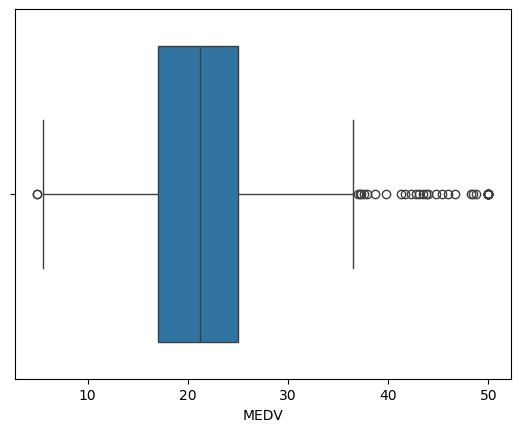

In [6]:
#Para o "Median value of owner-occupied homes" (Valor médio das residências ocupadas pelos proprietários), forneça um boxplot
#ax = sns.boxplot(x="MEDV", data=boston_df)
ax = sns.boxplot(x=boston_df["MEDV"])

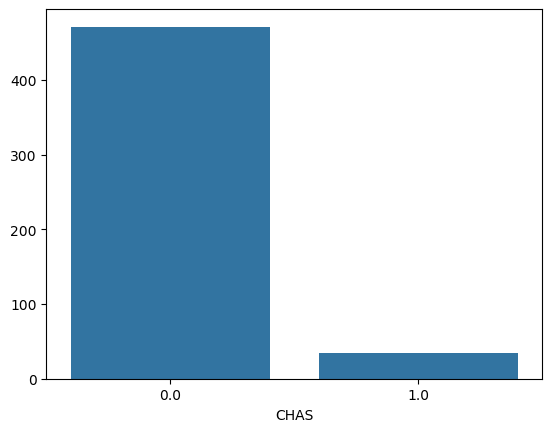

In [7]:
#Forneça um gráfico de barras para a variável Charles river
chas_counts = boston_df["CHAS"].value_counts().sort_index()
ax = sns.barplot(x=chas_counts.index, y=chas_counts.values)

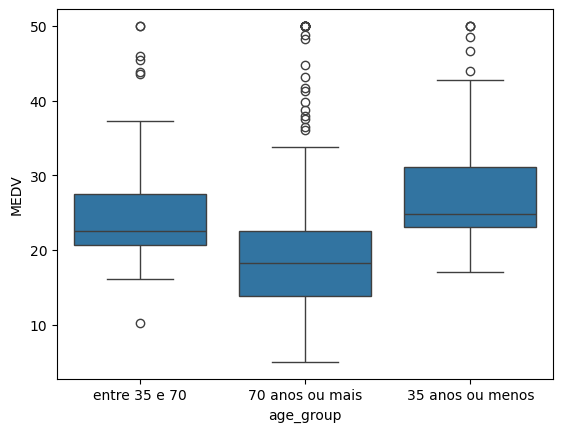

In [8]:
#Forneça um boxplot para a variável MEDV versus a variável AGE. (Discretize a variável idade em três grupos de 35 anos ou menos, entre 35 e 70 anos e 70 anos ou mais)
boston_df.loc[(boston_df['AGE'] <= 35), 'age_group'] = '35 anos ou menos'
boston_df.loc[(boston_df['AGE'] > 35)&(boston_df['AGE'] <= 70), 'age_group'] = 'entre 35 e 70'
boston_df.loc[(boston_df['AGE'] > 70), 'age_group'] = '70 anos ou mais'
ax = sns.boxplot(x="age_group", y="MEDV", data=boston_df)

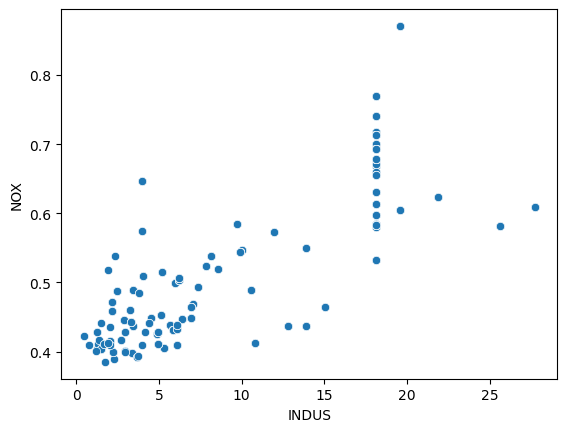

In [9]:
#Forneça um gráfico de dispersão para mostrar a relação entre as concentrações de óxido nítrico e a proporção de acres de negócios não varejistas por cidade. O que o senhor pode dizer sobre essa relação?
ax = sns.scatterplot(data=boston_df, x="INDUS", y="NOX")

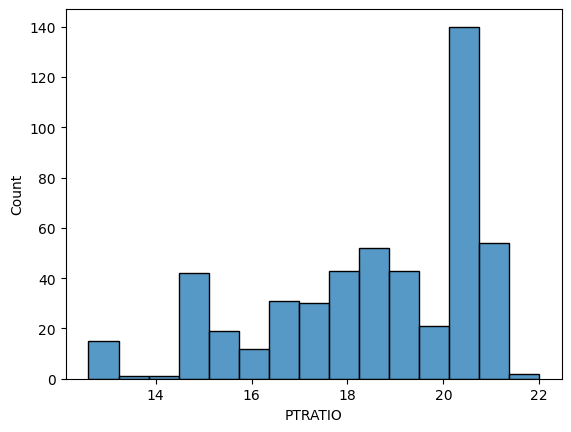

In [10]:
#Crie um histograma para a variável de proporção de alunos por professor
ax = sns.histplot(boston_df["PTRATIO"], bins=15, kde=False)

In [17]:
#Existe uma diferença significativa no valor médio das casas delimitadas pelo rio Charles ou não? (Teste T para amostras independentes)
medv_river = boston_df[boston_df["CHAS"] == 1]["MEDV"]
medv_nonriver = boston_df[boston_df["CHAS"] == 0]["MEDV"]

t_stat, p_value = scipy.stats.ttest_ind(medv_river, medv_nonriver, equal_var=False) #)

print(f"T-statistic: {t_stat}, p-value: {p_value}")
print("Existe diferença")

T-statistic: 3.113291312794837, p-value: 0.003567170098137517
Existe diferença


In [15]:
#Existe uma diferença no valor médio das residências (MEDV) para cada proporção de unidades ocupadas pelo proprietário construídas antes de 1940 (AGE)? (ANOVA)
boston_df.loc[(boston_df['AGE'] <= 35), 'age_group'] = '35 anos ou menos'
boston_df.loc[(boston_df['AGE'] > 35)&(boston_df['AGE'] <= 70), 'age_group'] = 'entre 35 e 70'
boston_df.loc[(boston_df['AGE'] > 70), 'age_group'] = '70 anos ou mais'

group1 = boston_df[boston_df["age_group"] == "35 anos ou menos"]["MEDV"]
group2 = boston_df[boston_df["age_group"] == "entre 35 e 70"]["MEDV"]
group3 = boston_df[boston_df["age_group"] == "70 anos ou mais"]["MEDV"]

f_stat, p_value = scipy.stats.f_oneway(group1, group2, group3)

print(f"F-statistic: {f_stat}, p-value: {p_value}")
print("Não existe diferença")

F-statistic: 36.40764999196599, p-value: 1.7105011022702984e-15
Não existe diferença


In [18]:
#Podemos concluir que não há relação entre as concentrações de óxido nítrico e a proporção de acres de negócios não varejistas por cidade? (Correlação de Pearson)
corr, p_value = scipy.stats.pearsonr(boston_df["NOX"], boston_df["INDUS"])
print(f"F-statistic: {f_stat}, p-value: {p_value}")
print("Existe uma correlação linear significativa entre (NOX) e (INDUS).")

F-statistic: 36.40764999196599, p-value: 7.913361061210442e-98
Existe uma correlação linear significativa entre (NOX) e (INDUS).


In [20]:
#Qual é o impacto de uma distância adicional ponderada para os cinco centros de emprego de Boston sobre o valor médio das residências ocupadas pelos proprietários? (Análise de regressão)
X = boston_df["DIS"]
y = boston_df["MEDV"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Thu, 22 May 2025   Prob (F-statistic):           1.21e-08
Time:                        00:24:52   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0